# PySINDy tutorial and practical tips


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.metrics import mean_squared_error
import pysindy as ps

# One figure style for every notebook of the pipeline.
# Purple leads the cycle (purple/orange is the default two-series pair).
COLORS = {"purple": "#5E3C99", "orange": "#D55E00", "green": "#009E73",
          "blue": "#0072B2", "brown": "#8C564B", "yellow": "#E69F00"}
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.size": 10,
    "mathtext.fontset": "stix",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
    "axes.xmargin": 0.0,       # sweep traces fill the full axis width
    "xtick.direction": "in",
    "ytick.direction": "in",
    "path.simplify": True,  # render-only; Agg cannot draw the 800 k-point records without it
    "agg.path.chunksize": 10000,  # draw long traces in chunks
    "axes.prop_cycle": plt.cycler(color=list(COLORS.values())),
})


In [2]:
m = 1.0  # kg
k = 4.0  # N/m

omega_n = np.sqrt(k / m)

print(f"omega_n = {omega_n:.3f} rad/s")
print(f"f_n = {omega_n/(2*np.pi):.3f} Hz")

omega_n = 2.000 rad/s
f_n = 0.318 Hz


In [3]:
def cubic_spring(t, z, m, k):
    x, v = z
    dxdt = v
    dvdt = -(k/m)*x**3
    return [dxdt, dvdt]

In [4]:
t = np.arange(0, 10, 0.01)

# Initial condition
x0 = 1.0
v0 = 0.0
z0 = [x0, v0]

sol = solve_ivp(
    fun=lambda t, z: cubic_spring(t, z, m, k),
    t_span=(0, 10),
    y0=z0,
    t_eval=t,
    rtol=1e-10,
    atol=1e-12
)

# State matrix
X = sol.y.T

print("Shape of X:", X.shape)
print("First rows of X:")
pd.DataFrame(X[:5], columns=["x", "v"])

Formato de X: (1000, 2)
Primeiras linhas de X:


,x,v
0,1.000000,0.000000
1,0.999800,-0.039992
2,0.999200,-0.079936
3,0.998202,-0.119784
4,0.996805,-0.159489


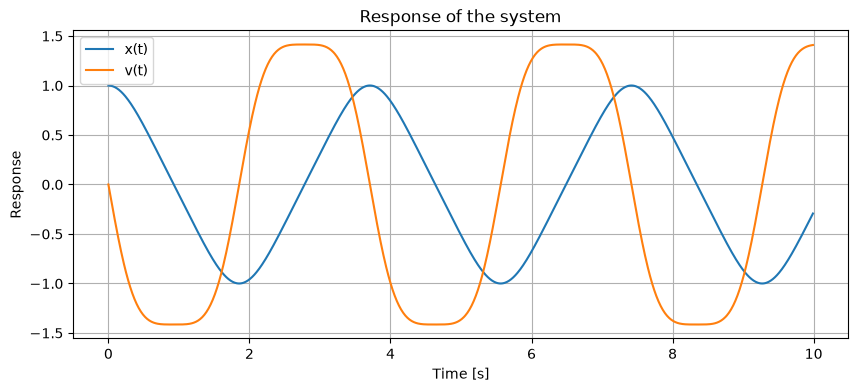

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(t, X[:, 0], label="x(t)")
plt.plot(t, X[:, 1], label="v(t)", alpha=0.55)
plt.xlabel("Time [s]")
plt.ylabel("Response")
plt.legend()
plt.grid(True)
plt.show()

## Use the default polynomial library


In [6]:
model = ps.SINDy()
print(model)

SINDy(differentiation_method=FiniteDifference(axis=-2),
      feature_library=PolynomialLibrary(), optimizer=STLSQ())


In [7]:
model.fit(X, t=t)
model.print()

(x0)' =  1.000 x1
(x1)' =  0.454 1 + -2.922 x0 + -0.346 x0^2 + -0.232 x1^2


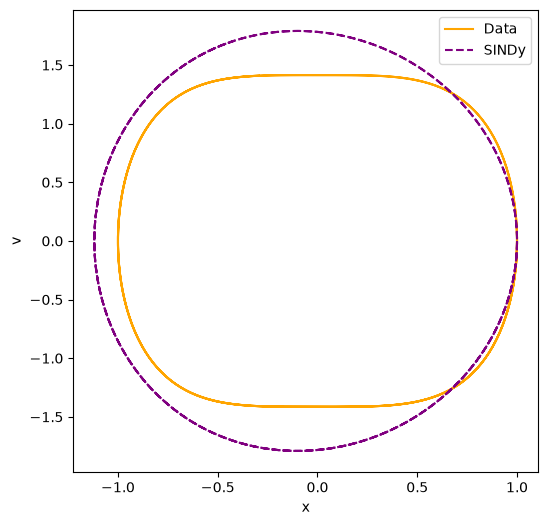

In [8]:
x_model = model.simulate(X[0, :], t)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(X[:, 0], X[:, 1], 'orange', label='Data')
ax.plot(x_model[:, 0], x_model[:, 1], color = 'purple', linestyle='--', label='SINDy', alpha=0.55)
ax.set(xlabel = 'x', ylabel = 'v')
ax.legend()
plt.show()  

## Use a Fourier library


In [9]:
fourier_library = ps.FourierLibrary(n_frequencies=2)

model = ps.SINDy(feature_library=fourier_library)
model.fit(X, t=t)
model.print()

(x0)' =  1.513 sin(1 x1) + -0.288 sin(2 x1)
(x1)' = -10.532 sin(1 x0) +  5.436 sin(2 x0)


C:\Users\anacs\AppData\Local\Temp\ipykernel_14860\3578966716.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


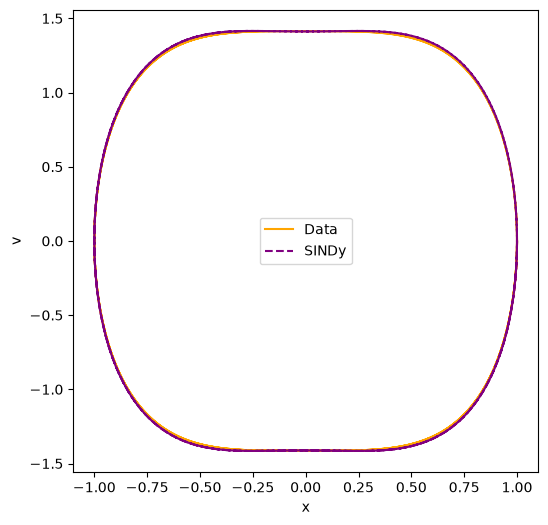

In [10]:
x_model = model.simulate(X[0, :], t)

fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.plot(X[:, 0], X[:, 1], 'orange', label='Data')
ax.plot(x_model[:, 0], x_model[:, 1], color = 'purple', linestyle='--', label='SINDy', alpha=0.55)
ax.set(xlabel = 'x', ylabel = 'v')
ax.legend()
fig.show()

## Increase the threshold and add a constant basis function


In [11]:
fourier_library = ps.FourierLibrary(
    n_frequencies=2,
    include_sin=True,
    include_cos=True
)

constant_library = ps.PolynomialLibrary(
    degree=0,
    include_bias=True
)

library = constant_library + fourier_library

optimizer = ps.STLSQ(
    threshold=0.2,
)

model = ps.SINDy(
    feature_library=library,
    optimizer=optimizer,
)

model.fit(X, t=t)
model.print()

(x0)' =  1.513 sin(1 x1) + -0.288 sin(2 x1)
(x1)' = -10.532 sin(1 x0) +  5.436 sin(2 x0)


C:\Users\anacs\AppData\Local\Temp\ipykernel_14860\1526294016.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


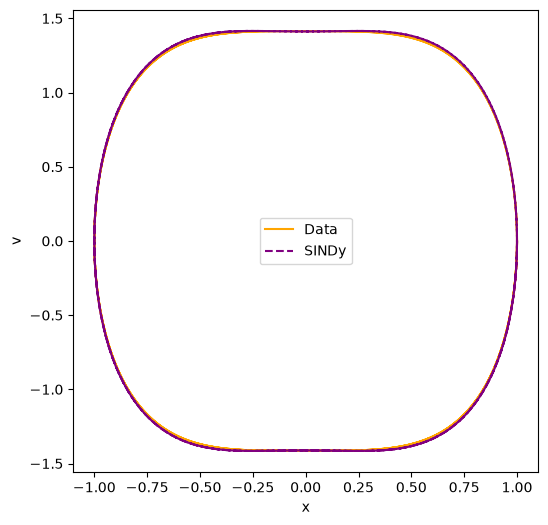

In [12]:
x_model = model.simulate(X[0,:], t)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(X[:, 0], X[:, 1], 'orange', label='Data')
ax.plot(x_model[:, 0], x_model[:, 1], color = 'purple', linestyle='--', label='SINDy', alpha=0.55)
ax.set(xlabel = 'x', ylabel = 'v')
ax.legend()
fig.show()

## Advanced features


- other optimizers, such as LASSO and ElasticNet
- additional methods for noisy data
- custom candidate-function libraries
- multiple initial conditions
- discrete-time dynamical systems
- built-in scoring functions


## Choose the threshold


In [13]:
opt = ps.STLSQ(threshold=0)
model = ps.SINDy(
    feature_library=library,
    optimizer=opt
)
model.fit(X, t=t)
model.print()

(x0)' =  1.293 1 + -0.004 sin(1 x0) + -1.628 cos(1 x0) +  1.513 sin(1 x1) + -0.276 cos(1 x1) +  0.003 sin(2 x0) +  0.405 cos(2 x0) + -0.288 sin(2 x1) +  0.030 cos(2 x1)
(x1)' = -7.009 1 + -10.532 sin(1 x0) +  8.952 cos(1 x0) +  0.002 sin(1 x1) +  1.353 cos(1 x1) +  5.436 sin(2 x0) + -2.269 cos(2 x0) + -0.004 sin(2 x1) + -0.120 cos(2 x1)


C:\Users\anacs\AppData\Local\Temp\ipykernel_14860\3568356048.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


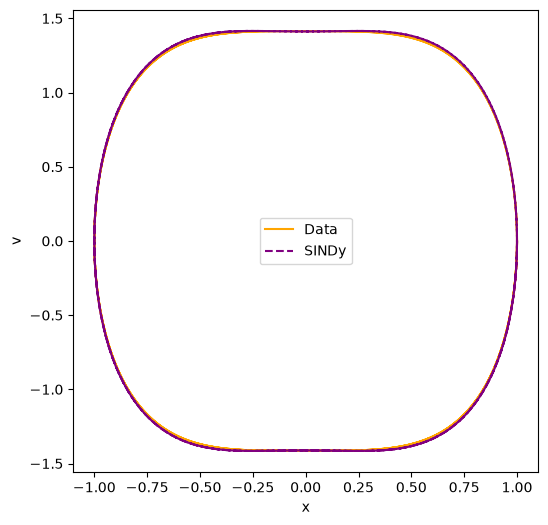

In [14]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(X[:, 0], X[:, 1], 'orange', label='Data')
ax.plot(x_model[:, 0], x_model[:, 1], color = 'purple', linestyle='--', label='SINDy', alpha=0.55)
ax.set(xlabel = 'x', ylabel = 'v')
ax.legend()
fig.show()

In [15]:
opt = ps.STLSQ(threshold=1)
model = ps.SINDy(
    feature_library=library,
    optimizer=opt
)
model.fit(X, t=t)
model.print()

(x0)' =  1.341 sin(1 x1)
(x1)' = -10.532 sin(1 x0) +  5.436 sin(2 x0)


C:\Users\anacs\AppData\Local\Temp\ipykernel_14860\3568356048.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


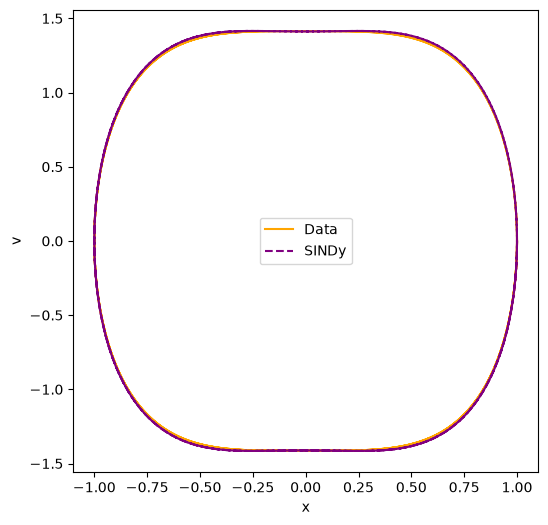

In [16]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(X[:, 0], X[:, 1], 'orange', label='Data')
ax.plot(x_model[:, 0], x_model[:, 1], color = 'purple', linestyle='--', label='SINDy', alpha=0.55)
ax.set(xlabel = 'x', ylabel = 'v')
ax.legend()
fig.show()

## Threshold scan


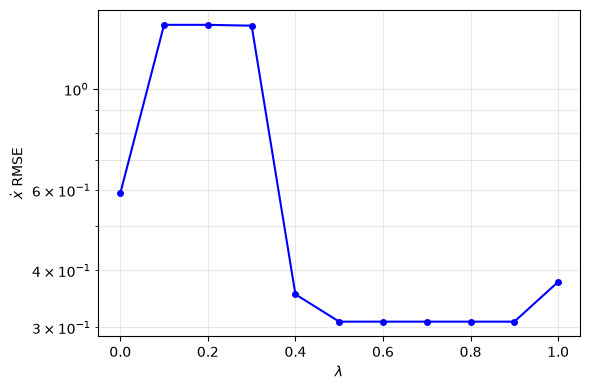

In [30]:
threshold_scan = np.linspace(0, 1, 11)

coefs = []
rmse_list = []

X_noise = X + 0.1 * np.random.randn(*X.shape)

for threshold in threshold_scan:
    opt = ps.STLSQ(threshold=threshold)

    model = ps.SINDy(
        feature_library=library,
        optimizer=opt
    )

    model.fit(X_noise, t=t)

    coefs.append(model.coefficients())

    x_pred = model.simulate(X[0, :], t)

    rmse_i = np.sqrt(mean_squared_error(X, x_pred))
    rmse_list.append(rmse_i)

plt.figure(figsize=(6, 4))
plt.semilogy(threshold_scan, rmse_list, "o-", color="blue", markersize=4)
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\dot{x}$ RMSE")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## Robust sparse system identification


### Finite differences


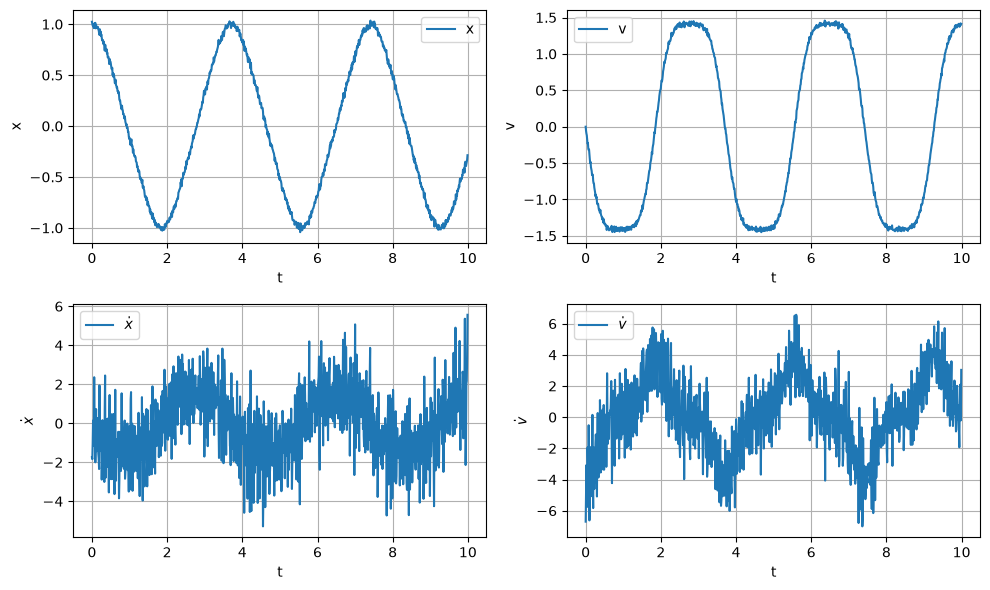

In [31]:
def plot_data_and_derivative(X_data, t, derivative_function):
    X_dot = derivative_function(X_data, t)

    labels = ["x", "v"]
    derivative_labels = [r"$\dot{x}$", r"$\dot{v}$"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))

    for i in range(2):
        axes[0, i].plot(t, X_data[:, i], alpha=0.55)
        axes[0, i].set_xlabel("t")
        axes[0, i].set_ylabel(labels[i])
        axes[0, i].legend([labels[i]])
        axes[0, i].grid(True)

    for i in range(2):
        axes[1, i].plot(t, X_dot[:, i], alpha=0.55)
        axes[1, i].set_xlabel("t")
        axes[1, i].set_ylabel(derivative_labels[i])
        axes[1, i].legend([derivative_labels[i]])
        axes[1, i].grid(True)

    plt.tight_layout()
    plt.show()


rmse = np.sqrt(mean_squared_error(X, np.zeros(X.shape)))

X_added_noise = X + np.random.normal(
    0,
    rmse / 50.0,
    X.shape
)

plot_data_and_derivative(
    X_added_noise,
    t,
    ps.FiniteDifference()._differentiate
)

### Smoothed finite differences


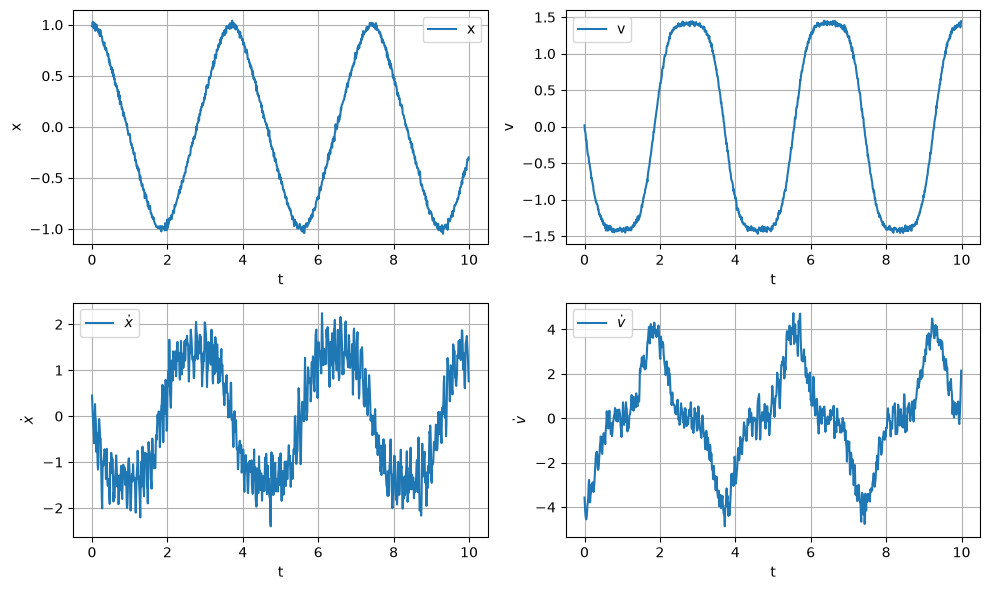

In [32]:
rmse = np.sqrt(mean_squared_error(X, np.zeros(X.shape)))

X_added_noise = X + np.random.normal(
    0,
    rmse / 50.0,
    X.shape
)

plot_data_and_derivative(
    X_added_noise,
    t,
    ps.SmoothedFiniteDifference()._differentiate
)

### Add more trajectories


In [35]:
n_trajectories = 40

x0s = (np.random.rand(n_trajectories, 2) - 0.5) * 4

x_train_multi = []
x_train_multi_clean = []

t_train = t
dt = t_train[1] - t_train[0]

for i in range(n_trajectories):
    sol_temp = solve_ivp(
        fun=lambda t, z: cubic_spring(t, z, m, k),
        t_span=(t_train[0], t_train[-1]),
        y0=x0s[i],
        t_eval=t_train,
        rtol=1e-10,
        atol=1e-12
    )

    x_train = sol_temp.y.T

    rmse = np.sqrt(mean_squared_error(x_train, np.zeros(x_train.shape)))

    x_train_added_noise = x_train + np.random.normal(
        0,
        rmse / 50.0,
        x_train.shape
    )

    x_train_multi.append(x_train_added_noise)
    x_train_multi_clean.append(x_train)


feature_names = ["x", "v"]

library_multi = ps.PolynomialLibrary(
    degree=3,
    include_bias=True
)

model = ps.SINDy(
    feature_library=library_multi,
    optimizer=ps.STLSQ(threshold=0.05)
)

model.fit(
    x_train_multi,
    t=dt,
)

model.print()

(x0)' =  0.999 x1
(x1)' = -0.214 x0 + -3.869 x0^3


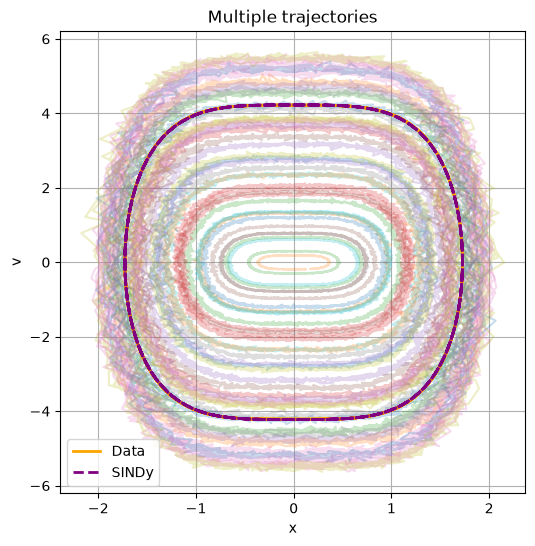

In [36]:
x_model = model.simulate(x_train_multi_clean[0][0, :], t_train)

fig, ax = plt.subplots(figsize=(6, 6))

for traj in x_train_multi:
    ax.plot(traj[:, 0], traj[:, 1], alpha=0.25)

ax.plot(
    x_train_multi_clean[0][:, 0],
    x_train_multi_clean[0][:, 1],
    color="orange",
    linewidth=2,
    label="Data",
    alpha=0.55,
)

ax.plot(
    x_model[:, 0],
    x_model[:, 1],
    color="purple",
    linestyle="--",
    linewidth=2,
    label="SINDy",
    alpha=0.55,
)

ax.set_xlabel("x")
ax.set_ylabel("v")
ax.legend()
ax.grid(True)

plt.show()

### Ensemble methods


In [47]:
x_train = X
dt = t[1] - t[0]

rmse = np.sqrt(mean_squared_error(x_train, np.zeros(x_train.shape)))

x_train_added_noise = x_train + np.random.normal(
    0,
    rmse / 20.0,
    x_train.shape
)

x = x_train_added_noise[:, 0]
v = x_train_added_noise[:, 1]

Theta = np.column_stack([
    np.ones_like(x),
    x,
    v,
    x**2,
    x*v,
    v**2,
    x**3,
    x**2*v,
    x*v**2,
    v**3
])

terms = [
    "1",
    "x",
    "v",
    "x²",
    "xv",
    "v²",
    "x³",
    "x²v",
    "xv²",
    "v³"
]

x_dot_train = np.gradient(x_train_added_noise, dt, axis=0)


def stlsq_manual(Theta, Xdot, threshold=0.05, max_iter=10):
    Xi = np.linalg.lstsq(Theta, Xdot, rcond=None)[0]

    for _ in range(max_iter):
        small = np.abs(Xi) < threshold
        Xi[small] = 0

        for j in range(Xdot.shape[1]):
            big = ~small[:, j]

            if np.any(big):
                Xi[big, j] = np.linalg.lstsq(
                    Theta[:, big],
                    Xdot[:, j],
                    rcond=None
                )[0]

    return Xi.T

In [48]:
n_models = 50
n_samples = Theta.shape[0]
n_subset = int(0.7 * n_samples)

coef_list = []

for i in range(n_models):
    idx = np.random.choice(
        np.arange(n_samples),
        size=n_subset,
        replace=True
    )

    coef = stlsq_manual(
        Theta[idx],
        x_dot_train[idx],
        threshold=0.05
    )

    coef_list.append(coef)

coef_list = np.array(coef_list)

mean_ensemble = np.mean(coef_list, axis=0)
std_ensemble = np.std(coef_list, axis=0)

In [49]:
n_models = 50
n_features = Theta.shape[1]
n_targets = x_train_added_noise.shape[1]

coef_library_list = []

for i in range(n_models):
    keep = np.ones(n_features, dtype=bool)

    drop_index = np.random.choice(
        np.arange(n_features),
        size=1,
        replace=False
    )

    keep[drop_index] = False

    coef_reduced = stlsq_manual(
        Theta[:, keep],
        x_dot_train,
        threshold=0.05
    )

    coef_full = np.zeros((n_targets, n_features))
    coef_full[:, keep] = coef_reduced

    coef_library_list.append(coef_full)

coef_library_list = np.array(coef_library_list)

mean_library_ensemble = np.mean(coef_library_list, axis=0)
std_library_ensemble = np.std(coef_library_list, axis=0)

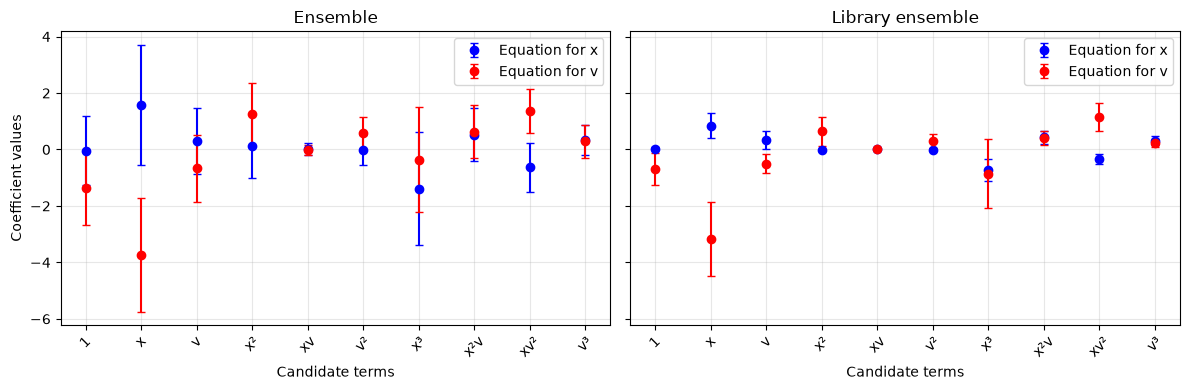

In [50]:
x_pos = np.arange(len(terms))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

equation_labels = ["Equation for x", "Equation for v"]
colors = ["blue", "red"]

for eq in range(2):
    axes[0].errorbar(
        x_pos,
        mean_ensemble[eq],
        yerr=std_ensemble[eq],
        fmt="o",
        color=colors[eq],
        label=equation_labels[eq],
        capsize=3,
        alpha=0.55,
    )

axes[0].set_xlabel("Candidate terms")
axes[0].set_ylabel("Coefficient values")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(terms, rotation=45)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for eq in range(2):
    axes[1].errorbar(
        x_pos,
        mean_library_ensemble[eq],
        yerr=std_library_ensemble[eq],
        fmt="o",
        color=colors[eq],
        label=equation_labels[eq],
        capsize=3,
        alpha=0.55,
    )

axes[1].set_xlabel("Candidate terms")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(terms, rotation=45)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Use physical knowledge to constrain the model
